In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set_full = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_set_full = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)
train_indices = np.random.choice(len(train_set_full), 20000, replace=False)
test_indices = np.random.choice(len(test_set_full), 5000, replace=False)
train_set = Subset(train_set_full, train_indices)
test_set = Subset(test_set_full, test_indices)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

In [2]:
for batch in train_loader:
    break

print(len(batch))
print(batch[0].shape)
print(batch[1].shape)

2
torch.Size([64, 1, 28, 28])
torch.Size([64])


In [ ]:
from torch import nn

class CNN(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        hidden_dim,
        kernel_size=1,
        stride=1,
        padding=0,
    ):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=hidden_dim,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )
        # self.norm1 = nn.BatchNorm2d(num_features=hidden_dim)
        self.act = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(
            in_channels=hidden_dim,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )
        # self.norm2 = nn.BatchNorm2d(num_features=out_channels)
        
        # 28 x 28 -> 14 x 14 -> 7 x 7
        # hard code here, add assertion
        # self.global_pool = nn.AdaptiveMaxPool2d is a better choice 
        assert (kernel_size - 1) // 2 == padding
        self.fc = nn.Linear(in_features=out_channels * 49, out_features=10)
    
    def forward(self, x):
        x = self.pool(self.act(self.conv1(x)))
        x = self.pool(self.act(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

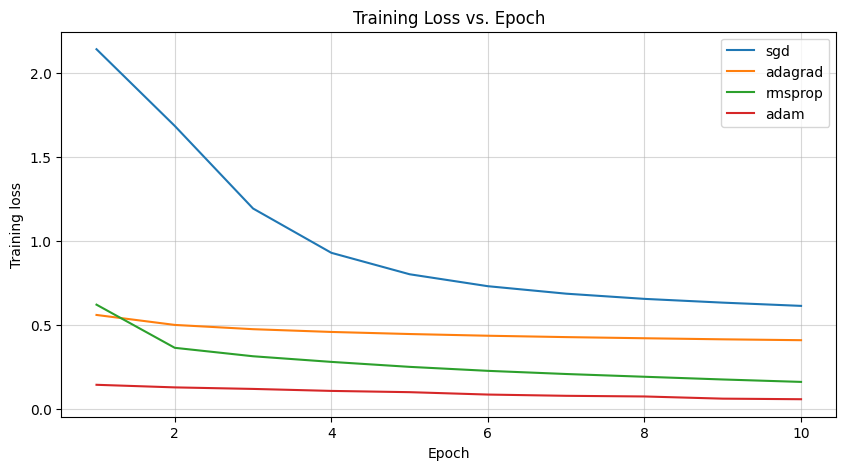

In [8]:
def train(
    model,
    dataloader,
    device,
    optimizer,
    criterion,
    epochs
):
    model.train()
    losses = []
    for _ in range(epochs):
        e_loss = 0.
        for img, label in dataloader:
            bsz = img.size(0)
            optimizer.zero_grad()
            out = model(img.to(device))
            loss = criterion(out, label.to(device))
            loss.backward()
            optimizer.step()
            e_loss += loss.item() * bsz

        e_loss /= len(dataloader.dataset)
        losses.append(e_loss)
        
    return losses

import matplotlib.pyplot as plt

def plot_fig(losses_list, optims):
    epochs = [i + 1 for i in range(len(losses_list[0]))]
    plt.figure(figsize=(10, 5))
    for name, loss in zip(optims, losses_list):
        plt.plot(epochs, loss, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("Training Loss vs. Epoch")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()

from torch.optim import SGD, Adagrad, RMSprop, Adam

model = CNN(in_channels=1, out_channels=64, hidden_dim=32, kernel_size=3, stride=1, padding=1)
device = 'cuda'
model.to(device)

optim_class = {
    "sgd": SGD(model.parameters(), lr=0.001, momentum=0),
    "adagrad": Adagrad(model.parameters(), lr=0.001),
    "rmsprop": RMSprop(model.parameters(), lr=0.001),
    "adam": Adam(model.parameters(), lr=0.001)
}
optims = ['sgd', 'adagrad', 'rmsprop', 'adam']
criterion = nn.CrossEntropyLoss()
epochs = 10
losses = []

for name in optims:
    optimizer = optim_class[name]
    losses.append(train(model, train_loader, device, optimizer, criterion, epochs))

plot_fig(losses, optims)